In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df_q2 = pd.read_csv(r'C:\Users\swaro\Downloads\q2_customers.csv')

# Scale features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_q2)

# Convert back to DataFrame for convenience
df_scaled = pd.DataFrame(df_scaled, columns=df_q2.columns)
df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


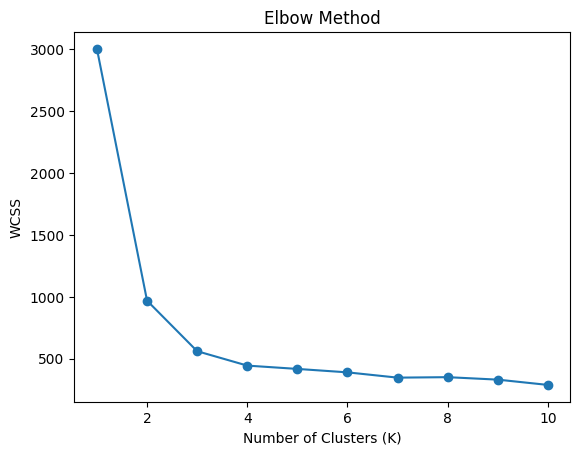

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [4]:
# Assuming K=4 based on the elbow plot
optimal_k = 4 
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df_q2['cluster'] = kmeans.fit_predict(df_scaled)

# Print Centroids
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                         columns=df_q2.columns[:-1])
print("Cluster Centroids:")
print(centroids)

Cluster Centroids:
         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  57.134146  89778.451220          2.463415  5345.500000   
2  40.387879  43340.733333          8.193939  2021.684848   
3  56.409639  89052.614458          2.590361  5713.361446   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             147.060976                  7.524390  
2              35.187879                  4.424242  
3              64.156627                  7.506024  


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pc_data = pca.fit_transform(df_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# Feature Loadings
loadings = pd.DataFrame(pca.components_.T, 
                        columns=['PC1', 'PC2'], 
                        index=df_q2.columns[:-1])
print("\nFeature Loadings:")
print(loadings)

Explained Variance Ratio: [0.83560354 0.05568764]

Feature Loadings:
                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


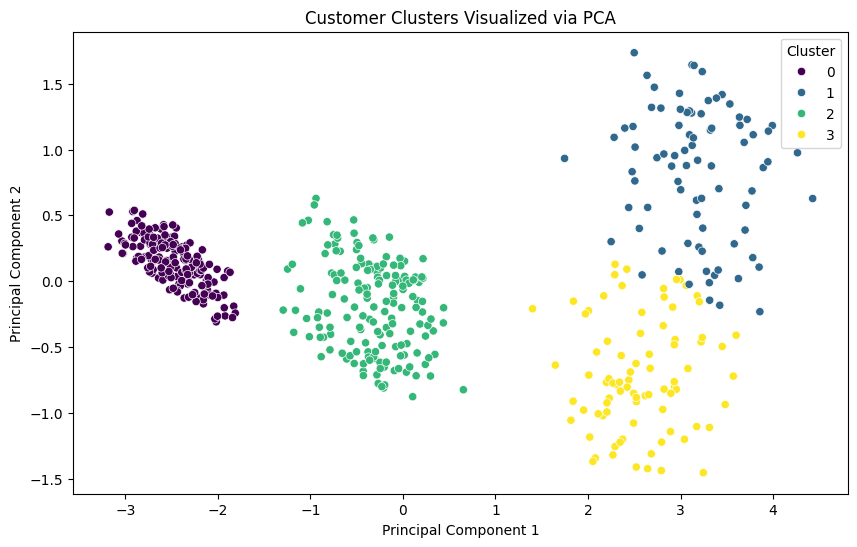

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Now your plotting code will work
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pc_data[:, 0], y=pc_data[:, 1], hue=df_q2['cluster'], palette='viridis')
plt.title('Customer Clusters Visualized via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()